#Análisis Exploratorio y Limpieza de Datos del Dataset TMDB + IMDB




#Pregunta de investigación
¿Qué factores influyen en el éxito y comportamiento de las películas según sus ingresos, popularidad y calificaciones?

#Contexto
En este proyecto se realiza un análisis exploratorio y proceso de limpieza sobre un dataset de películasobtenido de TMDB + IMDB. El objetivo es identificar factores relacionados con el éxito de las películas, como ingresos, popularidad, presupuesto y calificaciones. Para ello, se aplican técnicas de exploración de datos, detección de valores atípicos, correlación entre variables e imputación de datos faltantes mediante diferentes métodos estadísticos.

Carga librerias:

In [218]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
from sklearn.cluster import KMeans

In [219]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (3).json


{'kaggle (3).json': b'{"username":"RobertBR97","key":"KGAT_3890fe4dbb3c00a2d34101839700f30c"}'}

In [220]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [221]:
!kaggle datasets download ggtejas/tmdb-imdb-merged-movies-dataset

Dataset URL: https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset
License(s): CC-BY-NC-SA-4.0
tmdb-imdb-merged-movies-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [222]:
!unzip tmdb-imdb-merged-movies-dataset.zip -d datos/

Archive:  tmdb-imdb-merged-movies-dataset.zip
replace datos/TMDB  IMDB Movies Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [223]:
import pandas as pd
df = pd.read_csv('datos/TMDB  IMDB Movies Dataset.csv')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2819684,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2532759,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3170731,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1498792,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1559220,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [224]:
print("\nInformación general de las columnas:")
df.info()


Información general de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438387 entries, 0 to 438386
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    438387 non-null  int64  
 1   title                 438387 non-null  object 
 2   vote_average          438387 non-null  float64
 3   vote_count            438387 non-null  int64  
 4   status                438387 non-null  object 
 5   release_date          415963 non-null  object 
 6   revenue               438387 non-null  int64  
 7   runtime               438387 non-null  int64  
 8   adult                 438387 non-null  bool   
 9   backdrop_path         185743 non-null  object 
 10  budget                438387 non-null  int64  
 11  homepage              54935 non-null   object 
 12  tconst                438387 non-null  object 
 13  original_language     438387 non-null  object 
 14  original_title

In [225]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 438387
Número de variables: 29


In [226]:
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
object     19
int64       6
float64     3
bool        1
Name: count, dtype: int64


In [227]:
categoricas = df.select_dtypes(include=['object', 'bool']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

🔹 Variables categóricas:
- title
- status
- release_date
- adult
- backdrop_path
- homepage
- tconst
- original_language
- original_title
- overview
- poster_path
- tagline
- genres
- production_companies
- production_countries
- spoken_languages
- keywords
- directors
- writers
- cast

🔸 Variables numéricas:
- id
- vote_average
- vote_count
- revenue
- runtime
- budget
- popularity
- averageRating
- numVotes


In [228]:
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
                 id   vote_average     vote_count       revenue  \
count  4.383870e+05  438387.000000  438387.000000  4.383870e+05   
mean   4.983539e+05       3.586089      48.613878  1.660961e+06   
std    3.700222e+05       3.152571     511.454576  2.619674e+07   
min    2.000000e+00       0.000000       0.000000  0.000000e+00   
25%    2.112105e+05       0.000000       0.000000  0.000000e+00   
50%    4.211980e+05       4.514000       1.000000  0.000000e+00   
75%    7.166990e+05       6.200000       5.000000  0.000000e+00   
max    1.701000e+06      10.000000   34495.000000  2.923706e+09   

             runtime        budget     popularity  averageRating      numVotes  
count  438387.000000  4.383870e+05  438387.000000  438387.000000  4.383870e+05  
mean       66.413847  6.496849e+05       2.184109       6.222073  3.137004e+03  
std        64.204900  7.410380e+06      11.315664       1.311242  3.413603e+04  
min         0.000000  0.000000e+00 

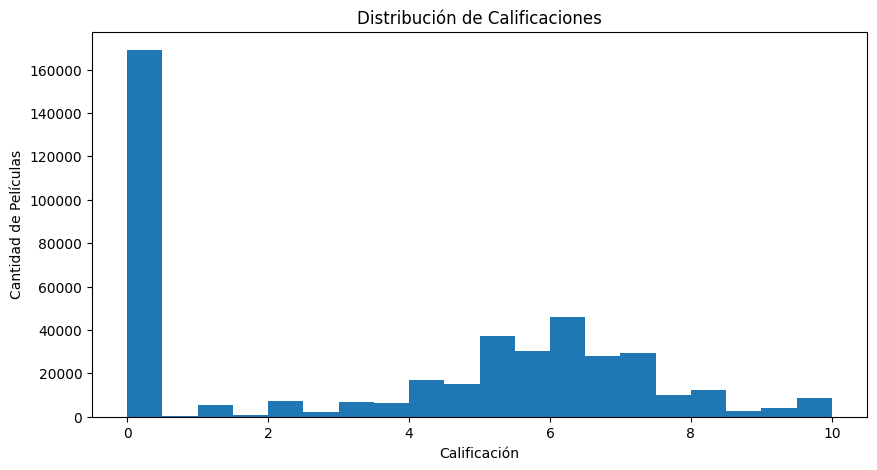

In [229]:
plt.figure(figsize=(10,5))

plt.hist(
    df['vote_average'].dropna(),
    bins=20
)

plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Cantidad de Películas')

plt.show()

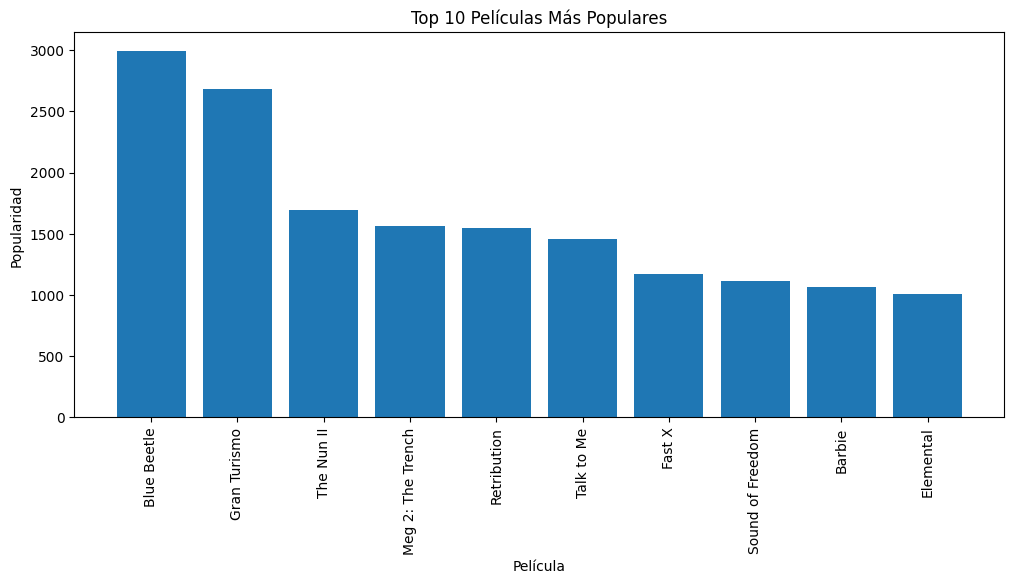

In [230]:
top_populares = df.sort_values(
    by='popularity',
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top_populares['title'],
    top_populares['popularity']
)

plt.xticks(rotation=90)

plt.title('Top 10 Películas Más Populares')
plt.xlabel('Película')
plt.ylabel('Popularidad')

plt.show()

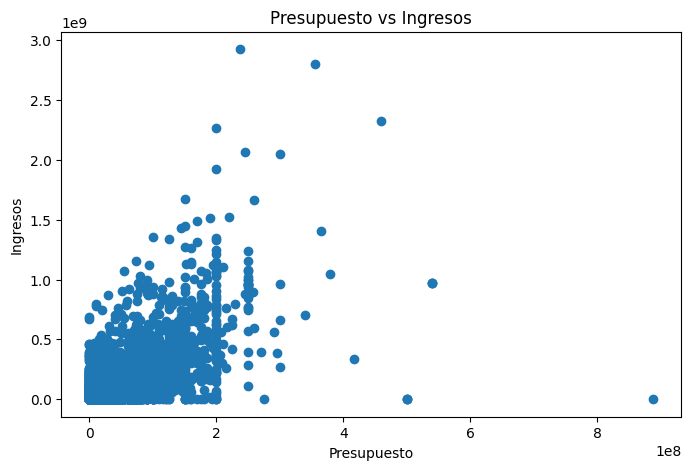

In [231]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['budget'],
    df['revenue']
)

plt.xlabel('Presupuesto')
plt.ylabel('Ingresos')
plt.title('Presupuesto vs Ingresos')

plt.show()

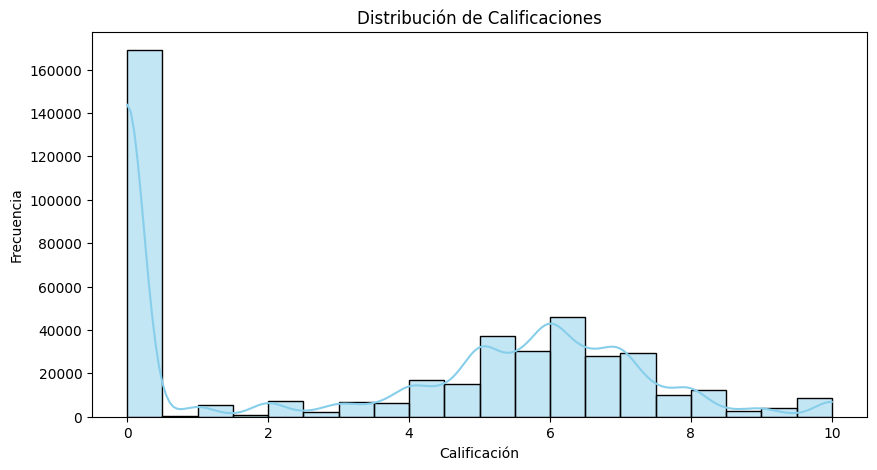

In [232]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['vote_average'].dropna(),
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia')

plt.show()

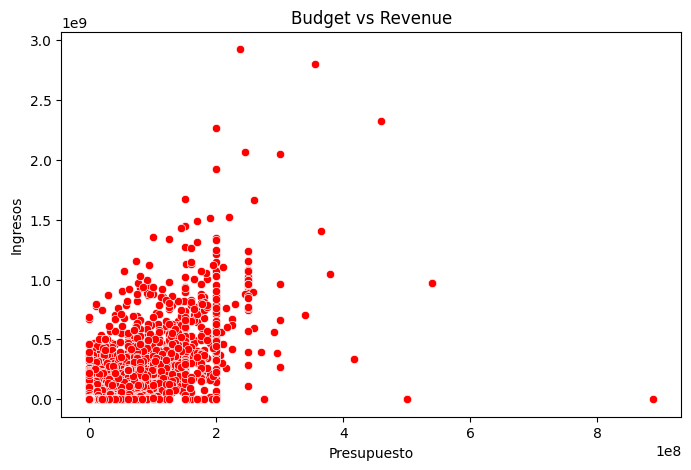

In [233]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['budget'],
    y=df['revenue'],
    color='red'
)

plt.title('Budget vs Revenue')
plt.xlabel('Presupuesto')
plt.ylabel('Ingresos')

plt.show()

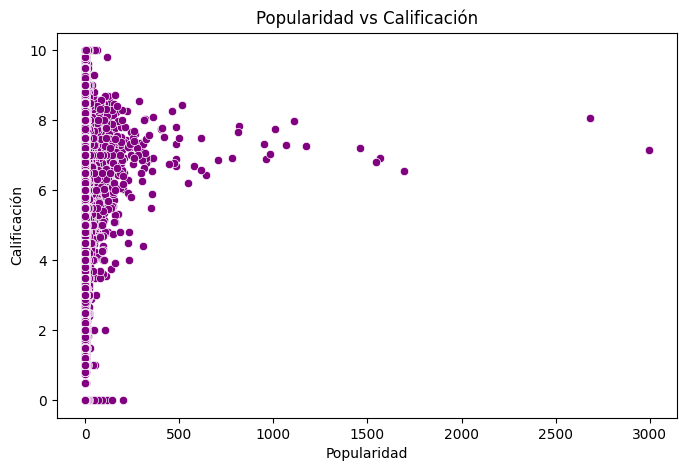

In [234]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['popularity'],
    y=df['vote_average'],
    color='purple'
)

plt.title('Popularidad vs Calificación')
plt.xlabel('Popularidad')
plt.ylabel('Calificación')

plt.show()

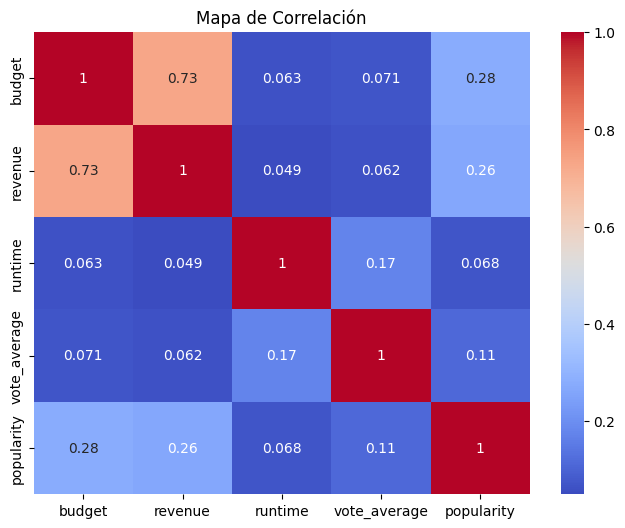

In [235]:
variables = [
    'budget',
    'revenue',
    'runtime',
    'vote_average',
    'popularity'
]

corr = df[variables].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de Correlación')

plt.show()

Aqui vemos que los ingresos y el presupuesto tienen una alta correlación

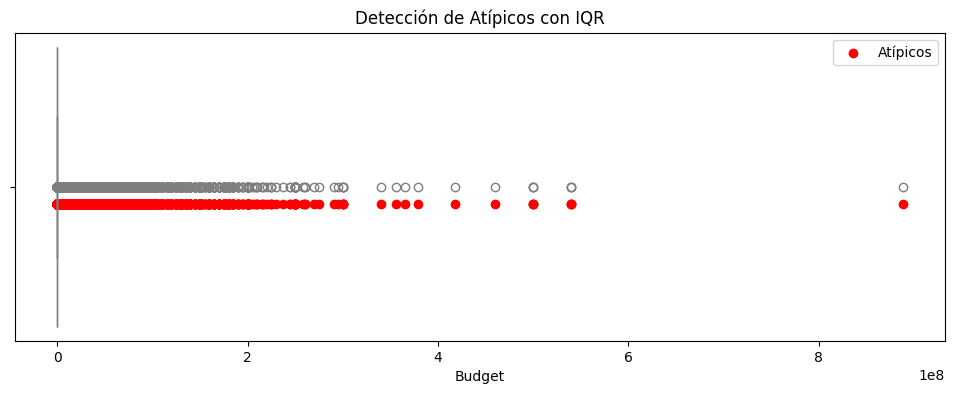

In [236]:
budget = df['budget'].dropna()

Q1, Q3 = np.percentile(budget, [25,75])

IQR = Q3 - Q1

lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR

atipicos = budget[
    (budget < lim_inf) |
    (budget > lim_sup)
]

plt.figure(figsize=(12,4))

sns.boxplot(
    x=budget,
    color='lightgray'
)

plt.scatter(
    atipicos,
    [0.05]*len(atipicos),
    color='red',
    label='Atípicos'
)

plt.xlabel('Budget')

plt.title('Detección de Atípicos con IQR')

plt.legend()

plt.show()

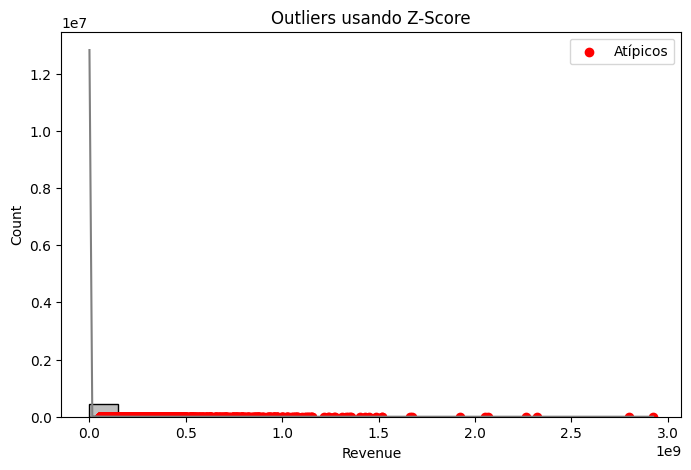

In [237]:
from scipy.stats import zscore

x = df['revenue'].dropna()

z_scores = zscore(x)

outliers = np.abs(z_scores) > 2

plt.figure(figsize=(8,5))

sns.histplot(
    x,
    bins=20,
    kde=True,
    color='gray'
)

plt.scatter(
    x[outliers],
    np.zeros_like(x[outliers]),
    color='red',
    label='Atípicos'
)

plt.title('Outliers usando Z-Score')
plt.xlabel('Revenue')

plt.legend()

plt.show()

In [238]:
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])


Conteo de valores faltantes por variable:
homepage                383452
tagline                 345766
keywords                267488
backdrop_path           252644
production_companies    176095
production_countries    117360
spoken_languages        105826
genres                   80804
poster_path              76806
cast                     69032
writers                  64983
overview                 43578
release_date             22424
directors                 9958
dtype: int64


In [239]:
nulos = df.isnull().sum()

nulos[nulos > 0]

,0
release_date,22424
backdrop_path,252644
homepage,383452
overview,43578
poster_path,76806
tagline,345766
genres,80804
production_companies,176095
production_countries,117360
spoken_languages,105826


In [240]:
titulos_duplicados = df.duplicated(subset=['title']).sum()

print(f"Número de películas con títulos duplicados: {titulos_duplicados}")

Número de películas con títulos duplicados: 68215


In [241]:
if titulos_duplicados > 0:
    peliculas_repetidas = df[df.duplicated(subset=['title'], keep=False)].sort_values(by='title')
    display(peliculas_repetidas.head(10))
else:
    print("No hay títulos repetidos.")

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
279284,1178778,"""Doctor Who"" The End of Time: Part One",0.0,0,Released,2009-12-25,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,Euros Lyn,"Russell T. Davies, Sydney Newman",8.3,7443,NaN
296487,1560219,"""Doctor Who"" The End of Time: Part One",0.0,0,Released,NaN,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,Euros Lyn,"Russell T. Davies, Sydney Newman",8.3,7443,NaN
279281,1178780,"""Doctor Who"" The End of Time: Part Two",0.0,0,Released,2010-01-01,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,Euros Lyn,"Russell T. Davies, Steven Moffat, Sydney Newman",8.9,8308,"David Tennant, John Simm, Bernard Cribbins"
279280,1178780,"""Doctor Who"" The End of Time: Part Two",0.0,0,Released,2010-01-01,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,Euros Lyn,"Russell T. Davies, Steven Moffat, Sydney Newman",8.9,8308,NaN
281956,1223874,"""Doctor Who"" The End of Time: Part Two",0.0,0,Released,2010-01-01,0,0,False,NaN,...,NaN,NaN,NaN,English,NaN,Euros Lyn,"Russell T. Davies, Steven Moffat, Sydney Newman",8.9,8308,NaN
281957,1223874,"""Doctor Who"" The End of Time: Part Two",0.0,0,Released,2010-01-01,0,0,False,NaN,...,NaN,NaN,NaN,English,NaN,Euros Lyn,"Russell T. Davies, Steven Moffat, Sydney Newman",8.9,8308,"David Tennant, John Simm, Bernard Cribbins"
298245,1642047,"""Paris 2024: XXXIII Olympic Summer Games"" Open...",0.0,0,Released,NaN,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,"Thomas Jolly, Simon Staffurth, Mike Sheehan","Patrick Boucheron, Aaron Cohen, Damien Gabriac...",6.2,347,"Jamel Debbouze, Zinédine Zidane, Lady Gaga, Ch..."
298246,1642047,"""Paris 2024: XXXIII Olympic Summer Games"" Open...",0.0,0,Released,NaN,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,"Thomas Jolly, Simon Staffurth, Mike Sheehan","Patrick Boucheron, Aaron Cohen, Damien Gabriac...",6.2,347,"Thomas Bach, Emmanuel Macron, Anne Hidalgo, Ja..."
218953,1261033,"""S""",10.0,1,Released,2012-05-05,0,8,False,NaN,...,Drama,NaN,Malta,English,NaN,Chris Zarb,Chris Zarb,8.9,17,"Jo Dyson, Michael Tabone, Mary Rose Mallia"
300396,1505805,"""S""",0.0,0,Released,2012-01-13,0,8,False,NaN,...,"Thriller, Drama",NaN,NaN,NaN,NaN,Chris Zarb,Chris Zarb,8.9,17,"Jo Dyson, Michael Tabone, Mary Rose Mallia"


In [242]:
df = df.drop_duplicates(subset=['title'], keep='first')

print("Dimensiones finales del dataset tras eliminar duplicados por título:")
print(df.shape)

Dimensiones finales del dataset tras eliminar duplicados por título:
(370172, 29)


In [243]:
columna_id = 'id'

if columna_id in df.columns:

    total_id_duplicados = df.duplicated(subset=[columna_id]).sum()
    print(f"Número de registros que son copias de un ID existente: {total_id_duplicados}")

    filas_id_duplicadas = df[df.duplicated(subset=[columna_id], keep=False)].sort_values(by=columna_id)

    print("\n Muestra de las películas con identificadores duplicados:")
    display(filas_id_duplicadas.head(10))
else:
    print(f"La columna '{columna_id}' no se encuentra en el DataFrame. Revisa el nombre exacto con df.info()")

Número de registros que son copias de un ID existente: 2

 Muestra de las películas con identificadores duplicados:


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
282403,1253313,"Bom Dia, Verônica",0.0,0,Released,2020-10-01,0,0,False,NaN,...,"Thriller, Mystery, Action, Crime",Zola Filmes,Brazil,NaN,NaN,"José Henrique Fonseca, Rog de Souza, Izabel Ja...","Gustavo Bragança, Ilana Casoy, Carol Garcia, D...",7.4,7355,NaN
282404,1253313,"Bom dia, Verônica",0.0,0,Released,NaN,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,"José Henrique Fonseca, Rog de Souza, Izabel Ja...","Gustavo Bragança, Ilana Casoy, Carol Garcia, D...",7.4,7355,NaN
289638,1294083,Doctor Who: The Legend of Ruby Sunday & Empire...,0.0,0,Post Production,2024-06-21,0,120,False,/piH7xPnsGRsihGZhD6uaZxh9A1G.jpg,...,"Science Fiction, Fantasy, Adventure, Family","BBC, Bad Wolf, BBC Studios",United Kingdom,English,"time travel, time machine, alien, lgbt, space ...",Jamie Donoughue,Russell T. Davies,6.3,5865,"Ncuti Gatwa, Millie Gibson, Jemma Redgrave, Ya..."
289642,1294083,Doctor Who: The Legend of Ruby Sunday / Empire...,0.0,0,Released,NaN,0,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,Jamie Donoughue,Russell T. Davies,6.3,5865,"Ncuti Gatwa, Millie Gibson, Jemma Redgrave, Ya..."


In [244]:
if 'id' in df.columns:
    id_duplicados = df.duplicated(subset=['id']).sum()
    print(f"Películas duplicadas por 'id': {id_duplicados}")

    df = df.drop_duplicates(subset=['id'], keep='first')

Películas duplicadas por 'id': 2


In [245]:
duplicados_anio = df.duplicated(subset=['title', 'release_date']).sum()
print(f"Registros idénticos en Título y Año de estreno: {duplicados_anio}")

df = df.drop_duplicates(subset=['title', 'release_date'], keep='first')

Registros idénticos en Título y Año de estreno: 0


In [246]:
print("Dimensiones finales del dataset tras eliminar duplicados por título y año:")
print(df.shape)

Dimensiones finales del dataset tras eliminar duplicados por título y año:
(370170, 29)


In [247]:
filas_iniciales, columnas_iniciales = df.shape
print(f"Dimensiones antes de limpiar nulos: {filas_iniciales} filas y {columnas_iniciales} columnas.")

df_limpio = df.dropna()

filas_finales, columnas_finales = df_limpio.shape
print(f"Dimensiones después de limpiar nulos (SP1): {filas_finales} filas y {columnas_finales} columnas.")

filas_eliminadas = filas_iniciales - filas_finales
porcentaje_perdido = (filas_eliminadas / filas_iniciales) * 100

print(f"\n Se eliminaron {filas_eliminadas} filas debido a valores faltantes.")
print(f"Pérdida del {porcentaje_perdido:.2f}% del conjunto de datos original.")

df = df_limpio.copy()

Dimensiones antes de limpiar nulos: 370170 filas y 29 columnas.
Dimensiones después de limpiar nulos (SP1): 7770 filas y 29 columnas.

 Se eliminaron 362400 filas debido a valores faltantes.
Pérdida del 97.90% del conjunto de datos original.


In [248]:
print("Dimensiones finales del dataset tras eliminar nulos:")
print(df.shape)

Dimensiones finales del dataset tras eliminar nulos:
(7770, 29)


In [249]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2819684,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2532759,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3170731,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1498792,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1559220,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


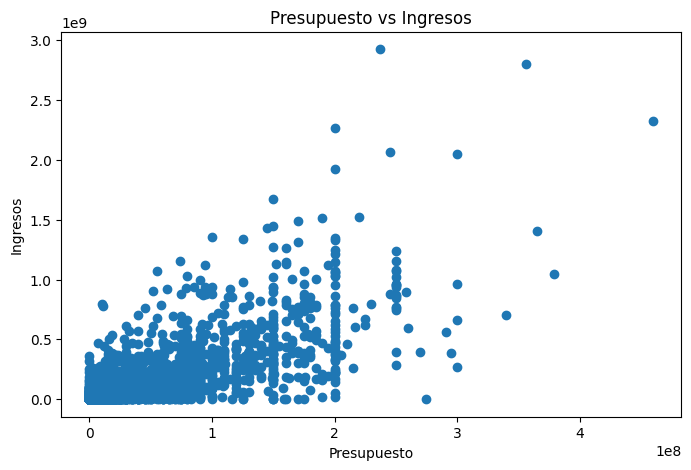

In [250]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['budget'],
    df['revenue']
)

plt.xlabel('Presupuesto')
plt.ylabel('Ingresos')
plt.title('Presupuesto vs Ingresos')

plt.show()

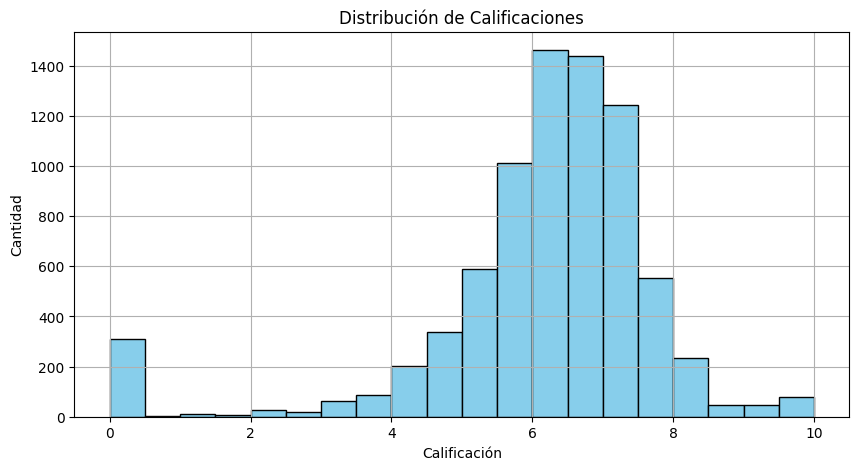

In [251]:
plt.figure(figsize=(10,5))

plt.hist(
    df['vote_average'].dropna(),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Cantidad')

plt.grid(True)

plt.show()

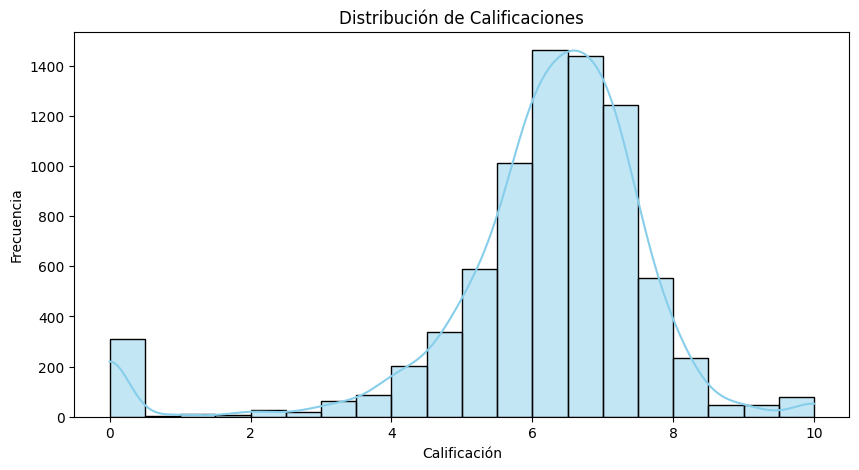

In [252]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['vote_average'].dropna(),
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia')

plt.show()

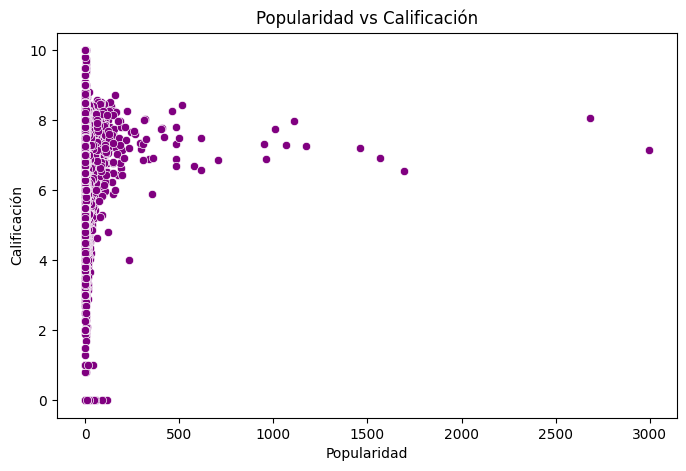

In [253]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['popularity'],
    y=df['vote_average'],
    color='purple'
)

plt.title('Popularidad vs Calificación')
plt.xlabel('Popularidad')
plt.ylabel('Calificación')

plt.show()

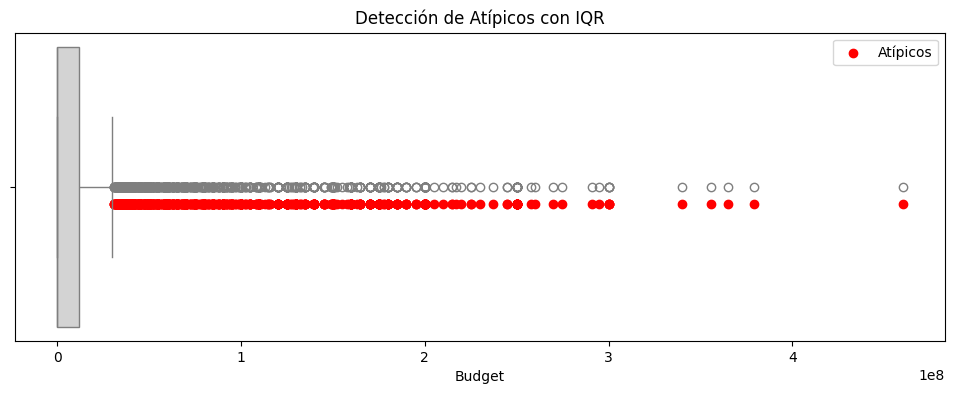

In [254]:
budget = df['budget'].dropna()

Q1, Q3 = np.percentile(budget, [25,75])

IQR = Q3 - Q1

lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR

atipicos = budget[
    (budget < lim_inf) |
    (budget > lim_sup)
]

plt.figure(figsize=(12,4))

sns.boxplot(
    x=budget,
    color='lightgray'
)

plt.scatter(
    atipicos,
    [0.05]*len(atipicos),
    color='red',
    label='Atípicos'
)

plt.xlabel('Budget')

plt.title('Detección de Atípicos con IQR')

plt.legend()

plt.show()

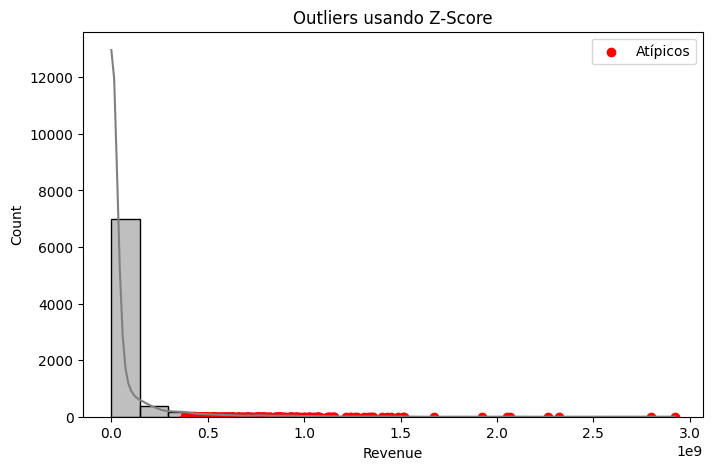

In [255]:
from scipy.stats import zscore

x = df['revenue'].dropna()

z_scores = zscore(x)

outliers = np.abs(z_scores) > 2

plt.figure(figsize=(8,5))

sns.histplot(
    x,
    bins=20,
    kde=True,
    color='gray'
)

plt.scatter(
    x[outliers],
    np.zeros_like(x[outliers]),
    color='red',
    label='Atípicos'
)

plt.title('Outliers usando Z-Score')
plt.xlabel('Revenue')

plt.legend()

plt.show()

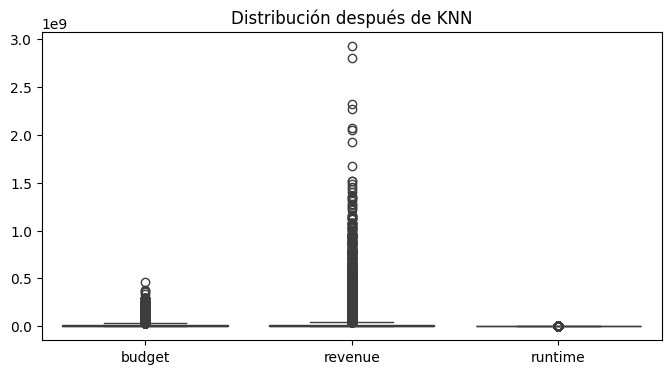

In [256]:
from sklearn.impute import KNNImputer

variables = [
    'budget',
    'revenue',
    'runtime'
]

knn = KNNImputer(n_neighbors=3)

df_knn = pd.DataFrame(
    knn.fit_transform(df[variables]),
    columns=variables
)

plt.figure(figsize=(8,4))

sns.boxplot(data=df_knn)

plt.title('Distribución después de KNN')

plt.show()

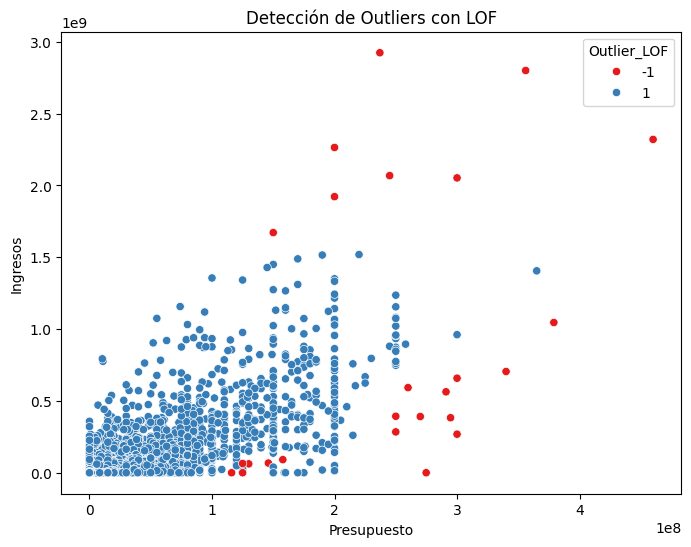

In [257]:
from sklearn.neighbors import LocalOutlierFactor

# Variables para el modelo
X = df[
    [
        'revenue',
        'budget',
        'popularity',
        'vote_average'
    ]
]

# Modelo LOF
lof = LocalOutlierFactor(
    n_neighbors=20
)

# Predicción de outliers
pred = lof.fit_predict(X)

# Crear columna en el dataframe
df['Outlier_LOF'] = pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='budget',
    y='revenue',
    hue='Outlier_LOF',
    palette='Set1'
)

plt.title('Detección de Outliers con LOF')

plt.xlabel('Presupuesto')

plt.ylabel('Ingresos')

plt.show()

El algoritmo (LOF) identificó múltiples películas con comportamientos diferentes a los de sus registros vecinos. En la gráfica, los puntos marcados en rojo corresponden a películas clasificadas como atípicas, ubicadas principalmente en zonas alejadas de la tendencia general entre el presupuesto (budget) y los ingresos (revenue). Se observan películas con presupuestos muy altos y bajos ingresos, así como películas con presupuestos moderados pero ingresos extremadamente elevados, lo que sugiere producciones con comportamientos poco comunes dentro del conjunto de datos.

#Conclusiones

El análisis exploratorio permitió identificar que variables como el presupuesto, la popularidad y las calificaciones influyen significativamente en el comportamiento y éxito de las películas. En general, las películas con mayores presupuestos tienden a generar mayores ingresos, aunque no siempre garantizan mejores calificaciones por parte del público.

Las gráficas de correlación y dispersión mostraron una relación positiva entre presupuesto e ingresos, evidenciando que las producciones con mayor inversión suelen alcanzar mejores resultados comerciales. Sin embargo, también se identificaron películas con presupuestos elevados y bajos ingresos, lo que demuestra que otros factores como la recepción del público y la popularidad también afectan el éxito de una película.

Mediante técnicas de detección de datos atípicos como IQR, Z-Score, gráficos de dispersión y Local Outlier Factor (LOF), se identificaron películas con comportamientos inusuales respecto a la tendencia general del dataset. Se encontraron casos de películas con ingresos extremadamente altos o bajos en comparación con su presupuesto, lo que evidencia comportamientos poco comunes dentro del mercado cinematográfico

Finalmente, el proyecto permitió integrar técnicas de exploración, limpieza, imputación y detección de atípicos dentro de un flujo completo de análisis de datos, concluyendo que el éxito y comportamiento de las películas depende de la combinación de múltiples factores, principalmente el presupuesto, los ingresos generados, la popularidad y la aceptación del público reflejada en las calificaciones.